<a href="https://colab.research.google.com/github/arav404/Trading/blob/main/brentvscrude.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pairs trading algorithm with backtesting and metrics between Crude and Brent


__Import modules__

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
from datetime import datetime
import copy
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from sklearn import model_selection as ms
from sklearn import linear_model as lm

## Creating strategy (regression, signals):

Load assets from tickers and plot

In [2]:
asset_1 = 'CL=F' #Crude Oil
asset_2 = 'BZ=F' #Brent Oil
tickers = [asset_1, asset_2]

start_date = datetime(2007, 1, 1)
end_date = datetime(2025, 1, 1)
data = yf.download(tickers, interval = '1d', start=start_date, end=end_date, ignore_tz = True, auto_adjust= True)['Close'].dropna()
data.head()

def is_cointegrated(series1, series2):
    # Combine into a dataframe and drop NA
    df = pd.DataFrame({'x': series1, 'y': series2}).dropna()

    # Run regression to find hedge ratio
    model = lm.LinearRegression()
    model.fit(df['x'].values.reshape(-1,1), df['y'].values)
    hedge_ratio = model.coef_[0]

    # Calculate spread
    spread = df['y'] - hedge_ratio * df['x']

    # ADF test on spread
    result = adfuller(spread)
    return result[1] < 0.05  # p-value threshold

is_cointegrated(data[asset_1], data[asset_2])

[*********************100%***********************]  2 of 2 completed


np.True_

Load into training and testing arrays and plot time series, print correlation and plot correlation heatmap

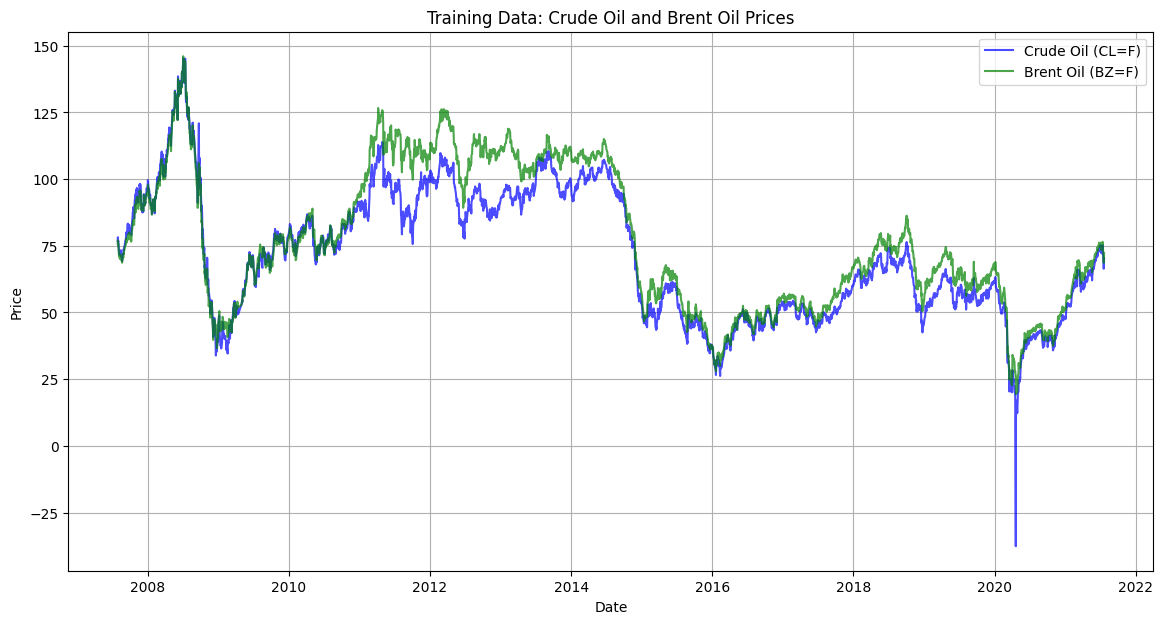

Correlation between Crude Oil and Brent Oil: 0.9732676445991068


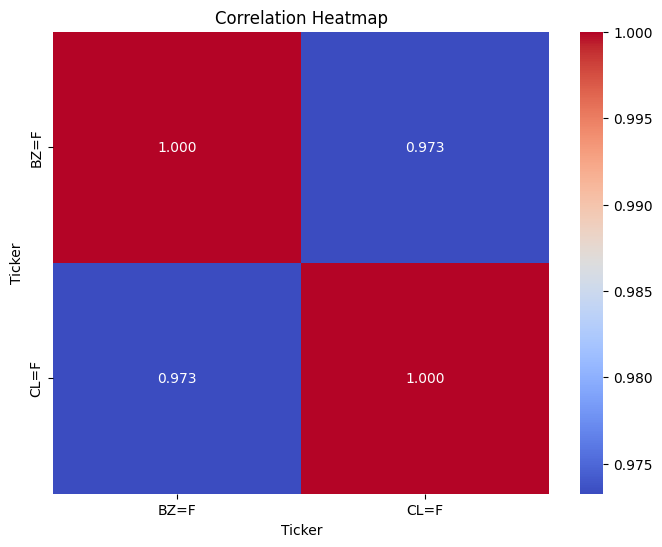

In [3]:
train, test = ms.train_test_split(data, shuffle = False, test_size = 0.2)

plt.figure(figsize=(14, 7))
plt.plot(train.index, train[asset_1], label='Crude Oil (CL=F)', color='blue', alpha=0.7)
plt.plot(train.index, train[asset_2], label='Brent Oil (BZ=F)', color='green', alpha=0.7)
plt.title('Training Data: Crude Oil and Brent Oil Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()

# Calculate and print correlation
correlation = train.corr()
print("Correlation between Crude Oil and Brent Oil:", correlation.loc[asset_1, asset_2])

# Plot heatmap of correlation
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', cbar=True, fmt=".3f")
plt.title('Correlation Heatmap')
plt.show()

Linear regression:

In [4]:
X = train[asset_1].values.reshape(-1, 1)  # Crude Oil prices as independent variable
Y = train[asset_2].values  # Brent Oil prices as dependent variable

model = lm.LinearRegression()
model.fit(X, Y)

# Calculate gradient, intercept, and R^2 coefficient
gradient = model.coef_[0]
intercept = model.intercept_
R2_coeff = model.score(X, Y)


print("R^2 Coefficient: ", R2_coeff)
print("Gradient: ", gradient)
print("Intercept: ", intercept)

R^2 Coefficient:  0.9472499080234956
Gradient:  1.0682659389002476
Intercept:  0.7683851589361126


Generate basic signal and plot:

In [5]:
x_scores_entering = np.linspace(0, -5, 1000)
x_scores_entering_2 = np.linspace(0, 5, 1000)
x_scores_exitting = np.linspace(-5, 0, 1000)
x_scores_exitting_2 = np.linspace(5, 0, 1000)


def basic_signal(z_score_array, trigger = 1, exit = 0):
    signal = np.zeros(len(z_score_array))
    position = 0  # 0 = no position, 1 = long, -1 = short

    for i, element in enumerate(z_score_array):
        if i == 0:
          signal[0] = 0
          continue

        if position == 0: # neither short or long
            if element > trigger:
                signal[i] = -1  # enter short
                position = -1 # record your position
                continue

            elif element < -trigger:
                signal[i] = 1   # enter long
                position = 1 #record your position
                continue

        elif position == -1:  # currently short
            if element <= exit:
                signal[i] = 0  # exit short
                position = 0  #record exit position
            else:
                signal[i] = -1  # stay short

        elif position == 1:  # currently long
            if element >= - exit:
                signal[i] = 0  # exit long
                position = 0 #record exit position
            else:
                signal[i] = 1  # stay long

    return signal




Generate tanh signal and plot:

In [6]:
def tanh_signal(z_score_array, z_score_scaling = 1, trigger = 1, exit = 0):
  signal = np.zeros(len(z_score_array))
  entered_long = False
  entered_short = False
  for i, element in enumerate(z_score_array):

      general_signal = -np.tanh(element/z_score_scaling)

      if i == 0:
        signal[i] = 0
        continue

      if not entered_long and not entered_short: #if no position
          if element > trigger:
              signal[i] = general_signal #enter short
              entered_short = True
              continue

          elif element < -trigger:
              signal[i] = general_signal #enter long
              entered_long = True
              continue

      elif entered_long: #already long
          if element >= -exit:
            signal[i] = 0 #exit long
            entered_long = False
          else:
            signal[i] = min(signal[i-1], general_signal) #maintain long

      elif entered_short: #already short
          if element <= exit:
            signal[i] = 0 #exit short
            entered_short = False
          else:
            signal[i] = max(signal[i-1], general_signal) #maintain short

  return signal


Last plots of signals for understanding

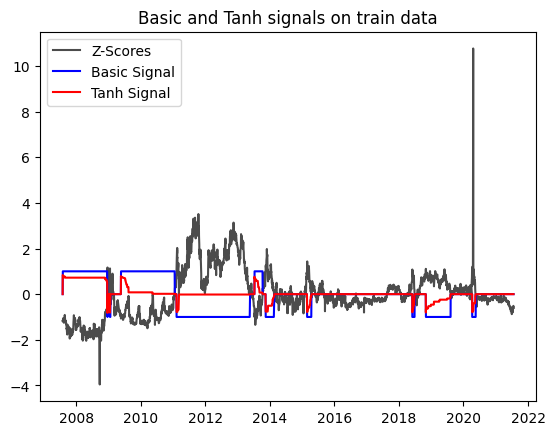

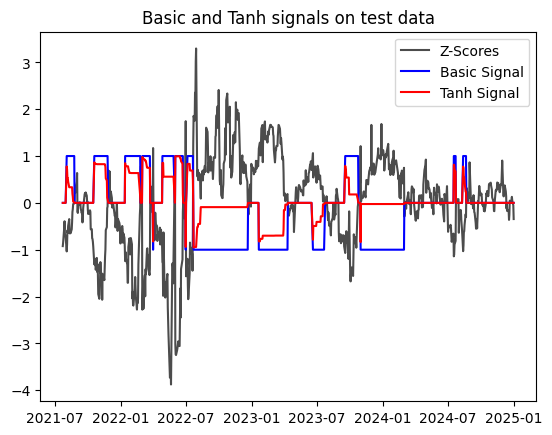

In [7]:
train['Spread'] = train[asset_2] - (gradient * train[asset_1] + intercept)
train['Z-Score'] = (train['Spread'] - train['Spread'].mean()) / train['Spread'].std()

test['Spread'] = test[asset_2] - (gradient * test[asset_1] + intercept)
test['Z-Score'] = (test['Spread'] - test['Spread'].mean()) / test['Spread'].std()

plt.plot(train.index, train['Z-Score'], label='Z-Scores', color='black', alpha=0.7)
plt.plot(train.index, basic_signal(train['Z-Score'].values), label='Basic Signal', color='blue')
plt.plot(train.index, tanh_signal(train['Z-Score'].values), label='Tanh Signal', color='red')
plt.title("Basic and Tanh signals on train data")
plt.legend()

plt.show()

plt.plot(test.index, test['Z-Score'], label='Z-Scores', color='black', alpha=0.7)
plt.plot(test.index, basic_signal(test['Z-Score'].values), label='Basic Signal', color='blue')
plt.plot(test.index, tanh_signal(test['Z-Score'].values), label='Tanh Signal', color='red')
plt.title("Basic and Tanh signals on test data")
plt.legend()

## Backtesting:

__backtest:__   Takes in a pair of time series, and the trade signal generated each day (without shifting - in practice we have to shift the signal by 1 so that day 1's signal affects the returns of the strategy on day1 --> day2).

It also has an optional parameter cumulative_returns which when True, shows how much money you'd make on $100 historically with this strategy, or returns the daily % PnL if __False__.

In [8]:
# Check if spread calculation aligns with economic logic
sample = train.sample(1)
cl_price, bz_price = sample[asset_1].item(), sample[asset_2].item()
current_spread = bz_price - gradient * cl_price

print(f"Current spread: {current_spread:.2f}")
print(f"Mean spread: {train['Spread'].mean():.2f}")
print(f"Z-score: {(current_spread - train['Spread'].mean())/train['Spread'].std():.2f}")

Current spread: 14.77
Mean spread: -0.00
Z-score: 2.45


Create z-scores:

In [9]:
def backtest(pair_time_series, unshifted_signal, cumulative_returns = True):
  asset_1 = pair_time_series.iloc[:,0]
  asset_2 = pair_time_series.iloc[:,1]

  change_in_price_asset_1 = asset_1.diff()
  change_in_price_asset_1.iloc[0] = 0
  change_in_price_asset_2 = asset_2.diff()
  change_in_price_asset_2.iloc[0] = 0

  signal_asset_1 = unshifted_signal*gradient
  signal_asset_2 = -unshifted_signal

  shifted_signal_asset_1 = np.roll(signal_asset_1,1)
  shifted_signal_asset_1[0] = 0


  shifted_signal_asset_2 = np.roll(signal_asset_2,1)
  shifted_signal_asset_2[0] = 0


  daily_returns_asset_1 = change_in_price_asset_1*shifted_signal_asset_1
  daily_returns_asset_2 = change_in_price_asset_2*shifted_signal_asset_2

  daily_returns = daily_returns_asset_1 + daily_returns_asset_2

  total_holdings = asset_1 * gradient + asset_2

  daily_percentage_returns = daily_returns / total_holdings

  if cumulative_returns:
    cumulative_pct_returns = 100*np.cumprod(1+daily_percentage_returns)
    return cumulative_pct_returns

  else:
    return daily_percentage_returns

Calculating performance metrics (Sharpe ratio):

In [10]:
def calc_sharpe(non_cumulative_return_time_series):
  mean_daily_return = np.mean(non_cumulative_return_time_series)
  mean_yearly_return = 252*mean_daily_return
  volatility_of_returns = np.std(non_cumulative_return_time_series)
  return (mean_yearly_return)/(np.sqrt(252)*volatility_of_returns)

## Final testing

In [11]:
# Generate signals for train data
basic_train_signal = basic_signal(train['Z-Score'])
tanh_train_signal = tanh_signal(train['Z-Score'])

# Backtest both strategies on train data
basic_train_returns = backtest(train, basic_train_signal, cumulative_returns=False)
tanh_train_returns = backtest(train, tanh_train_signal, cumulative_returns=False)
# print("Best day basic daily percentage returns", min(basic_train_returns))
# print("Best day tanh daily percentage returns", min(tanh_train_returns))

# Calculate Sharpe ratios
basic_sharpe_train = calc_sharpe(basic_train_returns)
tanh_sharpe_train = calc_sharpe(tanh_train_returns)

print(basic_sharpe_train)
print(tanh_sharpe_train)

0.37685511012919265
0.3691164827885449


In [12]:

# Generate signals for train data
basic_train_signal = basic_signal(train['Z-Score'].values)
tanh_train_signal = tanh_signal(train['Z-Score'].values)

# Backtest both strategies on train data
basic_train_returns = backtest(train, basic_train_signal, cumulative_returns=False)
tanh_train_returns = backtest(train, tanh_train_signal, cumulative_returns=False)
print("Best day basic daily percentage returns", max(basic_train_returns))
print("Best day tanh daily percentage returns", max(tanh_train_returns))

# Calculate Sharpe ratios
basic_sharpe_train = calc_sharpe(basic_train_returns)
tanh_sharpe_train = calc_sharpe(tanh_train_returns)

# Determine which strategy is better on train data
if basic_sharpe_train > tanh_sharpe_train:
    Better_Strategy = "Basic"
    B_S_Sharpe_Ratio = basic_sharpe_train
else:
    Better_Strategy = "Tanh"
    B_S_Sharpe_Ratio = tanh_sharpe_train

# Test data evaluation
test['Spread'] = test[asset_2] - (gradient * test[asset_1] + intercept)
test['Z-Score'] = (test['Spread'] - test['Spread'].mean()) / test['Spread'].std()

basic_test_signal = basic_signal(test['Z-Score'].values)
tanh_test_signal = tanh_signal(test['Z-Score'].values)

basic_test_returns = backtest(test, basic_test_signal, cumulative_returns=False)
tanh_test_returns = backtest(test, tanh_test_signal, cumulative_returns=False)

basic_sharpe_test = calc_sharpe(basic_test_returns)
tanh_sharpe_test = calc_sharpe(tanh_test_returns)

# Check if the better strategy on train is also better on test
if (Better_Strategy == "Basic" and basic_sharpe_test > tanh_sharpe_test) or \
   (Better_Strategy == "Tanh" and tanh_sharpe_test > basic_sharpe_test):
    True_or_False = "True"
else:
    True_or_False = "False"

print(basic_sharpe_test, basic_sharpe_train)
print(tanh_sharpe_test, tanh_sharpe_train)

# print(Better_Strategy, B_S_Sharpe_Ratio)
# print("Is it true for the test data: ", True_or_False)

# # Plot cumulative returns for both strategies
# plt.figure(figsize=(14, 7))
# plt.plot(train.index, backtest(train, basic_train_signal), label='Basic Strategy', color='blue')
# plt.plot(train.index, backtest(train, tanh_train_signal), label='Tanh Strategy', color='red')
# plt.title('Cumulative Returns of Both Strategies (Train Data)')
# plt.xlabel('Date')
# plt.ylabel('Cumulative Returns ($)')
# plt.legend()
# plt.grid()
# plt.show()

# plt.figure(figsize=(14, 7))
# plt.plot(test.index, backtest(test, basic_test_signal), label='Basic Strategy', color='blue')
# plt.plot(test.index, backtest(test, tanh_test_signal), label='Tanh Strategy', color='red')
# plt.title('Cumulative Returns of Both Strategies (Test Data)')
# plt.xlabel('Date')
# plt.ylabel('Cumulative Returns ($)')
# plt.legend()
# plt.grid()
# plt.show()

Best day basic daily percentage returns 5.159625426021971
Best day tanh daily percentage returns 3.8015494673131776
1.7670031040263463 0.37685511012919265
1.7802560652831834 0.3691164827885449
